# 4. Napelemes ML Pipeline – Day-Ahead Termelés-Előrejelzés (TFT)

**Cél:** A DuckDB-ben tárolt pvlib szimulációs adatokra (2023–2024) **Temporal Fusion Transformer (TFT)** modellt tanítunk, amely képes naponta 24 órával előre megjósolni a nettó AC termelést (`p_ac_net`) valószínűségi (P10/P50/P90) bizonytalansági sávokkal.

**Kapcsolat az 1-es notebookban:**
- Az `analysis.ipynb` elvégzi az ETL-t (OpenMeteo letöltés + pvlib szimuláció) és elmenti az adatokat a `solar_data.duckdb` adatbázisba.
- Ez a notebook onnan olvassa be az adatokat – a kettő közötti kapocs kizárólag a DuckDB fájl.

---
## 4.1. Importok és konfiguráció

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import math
import random
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Darts
import os
from darts import TimeSeries, concatenate as darts_concatenate
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import rmse as darts_rmse
from darts.utils.likelihood_models import QuantileRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Projekt konfiguráció
sys.path.insert(0, str(Path.cwd() / 'src'))
from config import (
    DB_PATH,
    LATITUDE, LONGITUDE,
    TIMEZONE,
    DETAILED_SYSTEM_LOSSES,
    DEGRADATION_YEAR1,
    DEGRADATION_ANNUAL,
    SIMULATION_BASE_YEAR,
    TRAIN_START, TRAIN_END,
    TEST_START, TEST_END,
    TFT_INPUT_LENGTH, TFT_OUTPUT_LENGTH,
    MPL_DEFAULTS, COLORS,
)

for k, v in MPL_DEFAULTS.items():
    matplotlib.rcParams[k] = v

print("Csomagok sikeresen betöltve.")
print(f"  Darts verzió  : {__import__('darts').__version__}")
print(f"  DuckDB elérési út: {DB_PATH}")

Csomagok sikeresen betöltve.
  Darts verzió  : 0.44.1
  DuckDB elérési út: data/solar_data.duckdb


---
## 4.2. Adatok betöltése DuckDB-ből

In [2]:
def load_ml_dataset(db_path: str = DB_PATH) -> pd.DataFrame:
    """Összekapcsolja a weather_data és pv_results táblákat, visszaadja az ML-hez szükséges DataFrame-et."""
    with duckdb.connect(db_path, read_only=True) as con:
        df = con.execute("""
            SELECT
                w.timestamp,
                w.ghi,
                w.temp_air,
                w.wind_speed,
                r.p_ac
            FROM weather_data w
            JOIN pv_results r ON w.timestamp = r.timestamp
            ORDER BY w.timestamp
        """).df()

    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_convert(TIMEZONE)
    df = df.set_index("timestamp").sort_index()
    return df

df_raw = load_ml_dataset()

print(f"Betöltött sorok : {len(df_raw):,}")
print(f"Időszak         : {df_raw.index[0].date()} – {df_raw.index[-1].date()}")
print(f"Oszlopok        : {list(df_raw.columns)}")
df_raw.head(3)

Betöltött sorok : 26,304
Időszak         : 2023-01-01 – 2026-01-01
Oszlopok        : ['ghi', 'temp_air', 'wind_speed', 'p_ac']


,ghi,temp_air,wind_speed,p_ac
timestamp,,,,
2023-01-01 01:00:00+01:00,0.0,7.7,3.51,0.0
2023-01-01 02:00:00+01:00,0.0,7.5,4.02,0.0
2023-01-01 03:00:00+01:00,0.0,7.3,4.14,0.0


---
## 4.3. Degradáció + rendszerveszteség → `p_ac_net` célváltozó

A Jinko Tiger Neo adatlap szerint:
- **1. év:** −1,0 % (LID + első év degradáció)
- **2+ év:** −0,4 % évente

A rendszerveszteség (soiling, árnyékolás, mismatch stb.) `DETAILED_SYSTEM_LOSSES`-ból számítódik.
A degradáció évente változik, így a modell **látens módon** megtanulja ezt a lassú csökkenést.

In [3]:
# Rendszerveszteség szorzó (időben állandó)
DERATE_FACTOR = math.prod(1.0 - loss for loss in DETAILED_SYSTEM_LOSSES.values())

# Kumulatív degradációs faktorok évenként
def _deg_factor(year: int) -> float:
    years_since_base = year - SIMULATION_BASE_YEAR
    if years_since_base <= 0:
        return 1.0 - DEGRADATION_YEAR1
    return (1.0 - DEGRADATION_YEAR1) * ((1.0 - DEGRADATION_ANNUAL) ** years_since_base)

years_in_data = sorted(df_raw.index.year.unique())
deg_map = {yr: _deg_factor(yr) for yr in years_in_data}

print("Degradációs faktorok:")
for yr, fac in deg_map.items():
    print(f"  {yr}: {fac:.5f}  (veszteség: {(1 - fac)*100:.3f} %)")
print(f"\nRendszerveszteség derate: {DERATE_FACTOR:.4f}  ({(1-DERATE_FACTOR)*100:.2f} %)")

df = df_raw.copy()
df["deg_factor"] = df.index.year.map(deg_map)
df["p_ac_net"] = df["p_ac"] * DERATE_FACTOR * df["deg_factor"]
df = df.drop(columns=["deg_factor", "p_ac"])

print(f"\np_ac_net max   : {df['p_ac_net'].max():.1f} W")
print(f"p_ac_net éves átlag (nappali): {df.loc[df['p_ac_net'] > 1, 'p_ac_net'].mean():.1f} W")

Degradációs faktorok:
  2023: 0.99000  (veszteség: 1.000 %)
  2024: 0.98604  (veszteség: 1.396 %)
  2025: 0.98210  (veszteség: 1.790 %)
  2026: 0.97817  (veszteség: 2.183 %)

Rendszerveszteség derate: 0.8679  (13.21 %)

p_ac_net max   : 2474.6 W
p_ac_net éves átlag (nappali): 1203.8 W


---
## 4.4. Időbeli feature-ök (ciklikus kódolás)

In [4]:
df["sin_hour"]  = np.sin(2 * np.pi * df.index.hour / 24)
df["cos_hour"]  = np.cos(2 * np.pi * df.index.hour / 24)
df["sin_month"] = np.sin(2 * np.pi * df.index.month / 12)
df["cos_month"] = np.cos(2 * np.pi * df.index.month / 12)

print("Feature-ök hozzáadva:")
print(df[["p_ac_net", "ghi", "temp_air", "wind_speed",
          "sin_hour", "cos_hour", "sin_month", "cos_month"]].describe().round(3))

Feature-ök hozzáadva:
        p_ac_net        ghi   temp_air  wind_speed   sin_hour   cos_hour  \
count  26304.000  26304.000  26304.000   26304.000  26304.000  26304.000   
mean     610.200    157.413     12.647       2.840     -0.000     -0.000   
std      881.881    234.022      9.080       1.508      0.707      0.707   
min        0.000      0.000     -8.300       0.000     -1.000     -1.000   
25%        0.000      0.000      5.200       1.730     -0.707     -0.707   
50%        6.688      6.000     12.400       2.560      0.000     -0.000   
75%     1115.700    263.000     19.700       3.750      0.707      0.707   
max     2474.621    925.000     37.400      10.780      1.000      1.000   

       sin_month  cos_month  
count  26304.000  26304.000  
mean      -0.005     -0.002  
std        0.706      0.708  
min       -1.000     -1.000  
25%       -0.866     -0.866  
50%       -0.000     -0.000  
75%        0.500      0.866  
max        1.000      1.000  


---
## 4.5. Darts `TimeSeries` konverzió

**Jövőbeli kovariánsok (future covariates):** a day-ahead időjárás-előrejelzésből ismert mennyiségek.
A backtestben a tényleges 2025-ös időjárási adatokat kezeljük úgy, mintha tökéletes másnapi előrejelzések lennének – ez a gördülő előrejelzés standard közelítése.

In [5]:
FUTURE_COV_COLS = [
    "ghi", "temp_air", "wind_speed",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
]

# Darts nem támogatja a timezone-aware DatetimeIndex-et.
# UTC-re konvertálunk, majd levetjük a tz-metaadatot → egyedi, DST-mentes index.
# A sin/cos feature-ök értékei a helyi időből már ki lettek számolva, maradnak helyesek.
df_utc = df.copy()
df_utc.index = df_utc.index.tz_convert("UTC").tz_localize(None)

ts_target = TimeSeries.from_series(
    df_utc["p_ac_net"].rename("p_ac_net"),
    freq="h",
    fill_missing_dates=True,
    fillna_value=0.0,
)

ts_future_cov = TimeSeries.from_dataframe(
    df_utc[FUTURE_COV_COLS],
    freq="h",
    fill_missing_dates=True,
    fillna_value=0.0,
)

print(f"Target TimeSeries  : {len(ts_target):,} időpont (UTC index)")
print(f"  Kezdet           : {ts_target.start_time()}")
print(f"  Vég              : {ts_target.end_time()}")
print(f"Future covariates  : {ts_future_cov.n_components} komponens")

Target TimeSeries  : 26,304 időpont (UTC index)
  Kezdet           : 2023-01-01 00:00:00
  Vég              : 2025-12-31 23:00:00
Future covariates  : 7 komponens


---
## 4.6. Train / Validáció / Test szétválasztás + skálázás

A tanítóhalmazt **2023-01 – 2024-09** adja, a validációs halmaz **2024-10 – 2024-12** (3 hónap).
A scaler-t **csak a tanítóhalmazon** illesztjük (data leakage elkerülése), majd a többi részre csak `transform()`-ot alkalmazunk.

In [6]:
def _to_utc(date_str: str) -> pd.Timestamp:
    """Helyi (Budapest) dátumot UTC naív Timestamp-pé alakít – összhangban a TimeSeries UTC indexével."""
    return pd.Timestamp(date_str, tz=TIMEZONE).tz_convert("UTC").tz_localize(None)

TRAIN_START_TS = _to_utc(TRAIN_START)
TEST_START_TS  = _to_utc(TEST_START)
TEST_END_TS    = _to_utc(TEST_END) + pd.Timedelta(hours=23)

# Validációs halmaz: 2024 utolsó 3 hónapja (okt–dec) → early stopping alapja
VAL_START_TS = _to_utc("2024-10-01")
VAL_END_TS   = _to_utc(TRAIN_END) + pd.Timedelta(hours=23)   # 2024-12-31 vége
FIT_END_TS   = VAL_START_TS - pd.Timedelta(hours=1)           # 2024-09-30 vége

# Tanítóhalmaz (2023-01 – 2024-09): scaler illesztéséhez + model fit
ts_train        = ts_target.slice(TRAIN_START_TS, FIT_END_TS)
ts_future_train = ts_future_cov.slice(TRAIN_START_TS, FIT_END_TS)

# Validációs halmaz (2024-10 – 2024-12)
ts_val          = ts_target.slice(VAL_START_TS, VAL_END_TS)
ts_future_val   = ts_future_cov.slice(VAL_START_TS, VAL_END_TS)

# Scaler-ek: csak a tanítóhalmazon illesztve (data leakage elkerülése)
scaler_target = Scaler(MinMaxScaler(feature_range=(0.0, 1.0)))
scaler_future = Scaler(StandardScaler())

ts_train_scaled        = scaler_target.fit_transform(ts_train)
ts_future_train_scaled = scaler_future.fit_transform(ts_future_train)

ts_val_scaled          = scaler_target.transform(ts_val)
ts_future_val_scaled   = scaler_future.transform(ts_future_val)

ts_target_full_scaled  = scaler_target.transform(ts_target)
ts_future_full_scaled  = scaler_future.transform(ts_future_cov)

print(f"Tanítás  : {ts_train.start_time()} – {ts_train.end_time()}  ({len(ts_train):,} óra)")
print(f"Validáció: {ts_val.start_time()} – {ts_val.end_time()}  ({len(ts_val):,} óra)")
print(f"Teszt    : {TEST_START_TS} – {TEST_END_TS} (UTC)")
print(f"\nTarget skálázva – min: {float(ts_train_scaled.values().min()):.4f}, max: {float(ts_train_scaled.values().max()):.4f}")

Tanítás  : 2023-01-01 00:00:00 – 2024-09-30 21:00:00  (15,334 óra)
Validáció: 2024-09-30 22:00:00 – 2024-12-31 22:00:00  (2,209 óra)
Teszt    : 2024-12-31 23:00:00 – 2025-12-31 22:00:00 (UTC)

Target skálázva – min: 0.0000, max: 1.0000


---
## 4.7. TFT modell felépítése

**Temporal Fusion Transformer** a Darts könyvtárból. `QuantileRegression` likelihood valószínűségi előrejelzéshez.

| Paraméter | Érték | Indoklás |
|---|---|---|
| `input_chunk_length` | 168 óra (7 nap) | Hetente ismétlődő mintázatok tanulása |
| `output_chunk_length` | 24 óra (1 nap) | Day-ahead predikciós horizont |
| `hidden_size` | 64 | Kompromisszum teljesítmény és sebesség között |
| `lstm_layers` | 2 | Kétszintű temporális kódolás |
| `num_attention_heads` | 4 | Multi-head attention |
| `n_epochs` | 20 | Elegendő konvergenciához, CPU-n ~5–15 perc |

In [7]:
FORCE_RETRAIN = False  # True: újratanít és felülírja a checkpointot
MODEL_CHECKPOINT_DIR = "darts_logs/solar_tft_model"

if not FORCE_RETRAIN and os.path.exists(MODEL_CHECKPOINT_DIR):
    try:
        # best=True: validációs loss alapján mentett legjobb checkpoint
        model = TFTModel.load_from_checkpoint("solar_tft_model", best=True, weights_only=False)
        print("Legjobb checkpoint betöltve (validációs loss alapján).")
    except Exception:
        # Visszaesés: régi checkpoint még nem tartalmaz best-*.ckpt fájlt
        model = TFTModel.load_from_checkpoint("solar_tft_model", best=False, weights_only=False)
        print("⚠  Validációs checkpoint nem található – utolsó epoch töltődött be.")
        print("   Újratanítás szükséges: FORCE_RETRAIN = True")
    _needs_training = False
    print(f"  Modell: {MODEL_CHECKPOINT_DIR}")
else:
    model = TFTModel(
        input_chunk_length=TFT_INPUT_LENGTH,
        output_chunk_length=TFT_OUTPUT_LENGTH,
        hidden_size=64,
        lstm_layers=2,
        num_attention_heads=4,
        dropout=0.1,
        batch_size=128,
        n_epochs=20,
        likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]),
        random_state=42,
        add_relative_index=True,
        pl_trainer_kwargs={
            "accelerator": "auto",
            "enable_progress_bar": True,
            "enable_model_summary": False,
        },
        optimizer_kwargs={"lr": 1e-3},
        model_name="solar_tft_model",
        save_checkpoints=True,
        force_reset=True,  # csak új tanításnál jutunk ide
    )
    _needs_training = True
    print("TFT modell létrehozva – tanítás szükséges.")

print(f"  Encoder ablak  : {TFT_INPUT_LENGTH} óra ({TFT_INPUT_LENGTH // 24} nap)")
print(f"  Predikció      : {TFT_OUTPUT_LENGTH} óra (day-ahead)")
print(f"  Kvantilesek    : P10 / P50 / P90")

FileNotFoundError: There is no file matching prefix best-* in D:\Workspace\solar-ml-pipeline\darts_logs\solar_tft_model\checkpoints


⚠  Validációs checkpoint nem található – utolsó epoch töltődött be.
   Újratanítás szükséges: FORCE_RETRAIN = True
  Modell: darts_logs/solar_tft_model
  Encoder ablak  : 168 óra (7 nap)
  Predikció      : 24 óra (day-ahead)
  Kvantilesek    : P10 / P50 / P90


---
## 4.8. Betanítás (2023–2024)

> CPU-n várható futásidő: **5–15 perc** (GPU esetén ~1–3 perc). Az `accelerator='auto'` automatikusan GPU-ra vált, ha elérhető.

In [8]:
if _needs_training:
    print("TFT modell betanítása...")
    model.fit(
        series=ts_train_scaled,
        future_covariates=ts_future_train_scaled,
        val_series=ts_val_scaled,
        val_future_covariates=ts_future_val_scaled,
        verbose=True,
    )
    print("\nBetanítás befejezve.")
else:
    print("Checkpoint már betöltve – betanítás kihagyva.")

Checkpoint már betöltve – betanítás kihagyva.


---
## 4.9. Gördülő day-ahead backtesting (2025)

A `historical_forecasts` minden nap éjfélkor a megelőző 7 nap alapján megjósolja a következő 24 óra termelését. Ez pontosan szimulálja a valós "day-ahead" üzemi forgatókönyvet.

**Adatszivárgás nincs:** a modell minden lépésben csak az adott időpontig ismert adatokat látja.

In [9]:
import pickle

BACKTEST_CACHE = "darts_logs/backtest_scaled.pkl"
FORCE_BACKTEST = False  # True: újra lefuttatja és felülírja a cache-t

if not FORCE_BACKTEST and os.path.exists(BACKTEST_CACHE):
    with open(BACKTEST_CACHE, "rb") as f:
        backtest_scaled = pickle.load(f)
    print(f"Backtest cache betöltve: {BACKTEST_CACHE}")
    print(f"  Előrejelzett ablakok: {len(backtest_scaled):,}")
else:
    print("Gördülő (rolling) day-ahead backtesting 2025-re...")
    print(f"  Időszak   : {TEST_START_TS.date()} – {TEST_END_TS.date()}")
    print(f"  Lépésköz  : {TFT_OUTPUT_LENGTH} óra (naponkénti)", flush=True)

    backtest_scaled = model.historical_forecasts(
        series=ts_target_full_scaled,
        future_covariates=ts_future_full_scaled,
        start=TEST_START_TS,
        forecast_horizon=TFT_OUTPUT_LENGTH,
        stride=TFT_OUTPUT_LENGTH,
        retrain=False,
        verbose=True,
        num_samples=100,
        overlap_end=False,
        last_points_only=False,
        enable_optimization=True,
    )

    with open(BACKTEST_CACHE, "wb") as f:
        pickle.dump(backtest_scaled, f)
    print(f"\nBacktest kész – cache mentve: {BACKTEST_CACHE}")
    print(f"  Előrejelzett ablakok: {len(backtest_scaled):,}")

Backtest cache betöltve: darts_logs/backtest_scaled.pkl
  Előrejelzett ablakok: 365


In [10]:
# backtest_scaled lista (365 × 24h) → egyetlen összefűzött TimeSeries → inverz skálázás
backtest = scaler_target.inverse_transform(darts_concatenate(backtest_scaled))
ts_test_actual = ts_target.slice(TEST_START_TS, TEST_END_TS)

print(f"Előrejelzések inverz transzformálva.")
print(f"  Backtest hossz : {len(backtest):,} óra")
print(f"  Tényleges hossz: {len(ts_test_actual):,} óra")

Előrejelzések inverz transzformálva.
  Backtest hossz : 8,760 óra
  Tényleges hossz: 8,760 óra


---
## 4.10. Metrikák: RMSE és MAPE

- **RMSE:** az összes 2025-ös órára (éjszakai nulla értékekkel együtt)
- **MAPE:** csak nappali órákra (`p_ac_net > 5 W`), mivel az éjszakai nulla termelés esetén a százalékos hiba értelmetlen

In [11]:
# Kvantilisek egyszeri számítása – egy menetben, ne hívjuk meg 5× külön-külön
_bv = backtest.all_values()   # (T, 1, n_samples) – egyszer allokálva
_t  = backtest.time_index
backtest_p10 = TimeSeries.from_times_and_values(_t, np.quantile(_bv, 0.1, axis=-1))
backtest_p50 = TimeSeries.from_times_and_values(_t, np.quantile(_bv, 0.5, axis=-1))
backtest_p90 = TimeSeries.from_times_and_values(_t, np.quantile(_bv, 0.9, axis=-1))

# Pandas Series-re konvertálás a metrikaszámításhoz
actual_s = ts_test_actual.to_dataframe().squeeze()
p50_s    = backtest_p50.to_dataframe().squeeze()

# Közös időpontok (robusztusság)
common_idx = actual_s.index.intersection(p50_s.index)
actual_s = actual_s.loc[common_idx]
p50_s    = p50_s.loc[common_idx]

# RMSE (minden óra)
rmse_val = np.sqrt(np.mean((actual_s - p50_s) ** 2))

# MAPE (csak nappali órák, ahol tényleges termelés > 5 W)
daytime = actual_s > 5.0
mape_val = np.mean(np.abs((actual_s[daytime] - p50_s[daytime]) / actual_s[daytime])) * 100

print("=" * 55)
print(f"  TFT Day-Ahead Előrejelzés – 2025-ös Teszt Eredmény")
print("=" * 55)
print(f"  RMSE (összes óra)    : {rmse_val:>8.2f} W")
print(f"  MAPE (nappali órák)  : {mape_val:>8.2f} %")
print(f"  Értékelt napok száma : {len(common_idx) // 24}")
print("=" * 55)

  TFT Day-Ahead Előrejelzés – 2025-ös Teszt Eredmény
  RMSE (összes óra)    :    46.88 W
  MAPE (nappali órák)  :     9.38 %
  Értékelt napok száma : 365


In [12]:
# ─── Forecast API: életszerű day-ahead kovariánsok + második backtest ────────
# Az ERA5 reanalízis (archive API) tökéletes időjárást ad inputként.
# Az OpenMeteo Historical Forecast API a valóban kiadott NWP-előrejelzéseket
# tárolja – ez szimulálja, hogy valós üzemben mit tudott volna a modell.
import requests as _rq

FORECAST_API_URL  = "https://historical-forecast-api.open-meteo.com/v1/forecast"
FC_COV_CACHE      = "darts_logs/ts_future_fc_scaled.pkl"
FC_BACKTEST_CACHE = "darts_logs/backtest_fc_scaled.pkl"
FORCE_FC          = False   # True: újra letölti a forecast kovariánsokat
FORCE_FC_BACKTEST = False   # True: újra futtatja a forecast backtestet

# ── 1. Forecast kovariánsok (2024-12-31 – 2025-12-31) ───────────────────────
if not FORCE_FC and os.path.exists(FC_COV_CACHE):
    with open(FC_COV_CACHE, "rb") as _f:
        ts_future_fc_full_scaled = pickle.load(_f)
    print(f"Forecast kovariáns cache betöltve: {FC_COV_CACHE}")
else:
    print("OpenMeteo Forecast API letöltése (2024-12-31 – 2025-12-31)...")
    _resp = _rq.get(FORECAST_API_URL, params={
        "latitude":        LATITUDE,
        "longitude":       LONGITUDE,
        "start_date":      "2024-12-31",
        "end_date":        "2025-12-31",
        "hourly":          "shortwave_radiation,direct_normal_irradiance,"
                           "diffuse_radiation,temperature_2m,windspeed_10m",
        "timezone":        "UTC",
        "wind_speed_unit": "ms",
    }, timeout=60)
    _resp.raise_for_status()

    _h = _resp.json()["hourly"]
    _df_fc = pd.DataFrame(_h).rename(columns={
        "time":                     "timestamp",
        "shortwave_radiation":      "ghi",
        "direct_normal_irradiance": "dni",
        "diffuse_radiation":        "dhi",
        "temperature_2m":           "temp_air",
        "windspeed_10m":            "wind_speed",
    })
    _df_fc["timestamp"] = pd.to_datetime(_df_fc["timestamp"]).dt.tz_localize("UTC")
    _df_fc = _df_fc.set_index("timestamp")
    for _c in ["ghi", "dni", "dhi"]:
        _df_fc[_c] = _df_fc[_c].clip(lower=0.0)

    # sin/cos features helyi időből számítva (konzisztens az eredeti pipeline-nal)
    _local_idx = _df_fc.index.tz_convert(TIMEZONE)
    _df_fc["sin_hour"]  = np.sin(2 * np.pi * _local_idx.hour  / 24)
    _df_fc["cos_hour"]  = np.cos(2 * np.pi * _local_idx.hour  / 24)
    _df_fc["sin_month"] = np.sin(2 * np.pi * _local_idx.month / 12)
    _df_fc["cos_month"] = np.cos(2 * np.pi * _local_idx.month / 12)
    _df_fc.index = _df_fc.index.tz_localize(None)  # UTC-naív (Darts elvárása)

    _ts_fc_raw = TimeSeries.from_dataframe(
        _df_fc[FUTURE_COV_COLS], freq="h",
        fill_missing_dates=True, fillna_value=0.0,
    )
    _ts_fc_scaled = scaler_future.transform(_ts_fc_raw)

    # Hibrid sorozat: archive 2023-2024 + forecast 2025
    _prefix  = ts_future_full_scaled.slice(
        ts_future_full_scaled.start_time(),
        TEST_START_TS - pd.Timedelta(hours=1),
    )
    _fc_part = _ts_fc_scaled.slice(TEST_START_TS, TEST_END_TS)
    ts_future_fc_full_scaled = darts_concatenate([_prefix, _fc_part])

    with open(FC_COV_CACHE, "wb") as _f:
        pickle.dump(ts_future_fc_full_scaled, _f)
    print("Forecast kovariáns cache mentve.")

print(f"Hibrid kovariáns: {len(ts_future_fc_full_scaled):,} óra  "
      f"(archive 2023-2024 + forecast 2025)")

# ── 2. Forecast-alapú gördülő backtest ──────────────────────────────────────
if not FORCE_FC_BACKTEST and os.path.exists(FC_BACKTEST_CACHE):
    with open(FC_BACKTEST_CACHE, "rb") as _f:
        _bt_fc_scaled = pickle.load(_f)
    print(f"Forecast backtest cache betöltve: {FC_BACKTEST_CACHE}")
else:
    print("Forecast-alapú gördülő backtest futtatása (2025)...")
    _bt_fc_scaled = model.historical_forecasts(
        series=ts_target_full_scaled,
        future_covariates=ts_future_fc_full_scaled,
        start=TEST_START_TS,
        forecast_horizon=TFT_OUTPUT_LENGTH,
        stride=TFT_OUTPUT_LENGTH,
        retrain=False,
        verbose=True,
        num_samples=100,
        overlap_end=False,
        last_points_only=False,
        enable_optimization=True,
    )
    with open(FC_BACKTEST_CACHE, "wb") as _f:
        pickle.dump(_bt_fc_scaled, _f)
    print("Forecast backtest cache mentve.")

# ── 3. Inverz transzformálás + p50 ──────────────────────────────────────────
_bt_fc     = scaler_target.inverse_transform(darts_concatenate(_bt_fc_scaled))
_bv_fc     = _bt_fc.all_values()
_t_fc      = _bt_fc.time_index
backtest_fc_p50 = TimeSeries.from_times_and_values(_t_fc, np.quantile(_bv_fc, 0.5, axis=-1))
p50_fc_s   = backtest_fc_p50.to_dataframe().squeeze().loc[common_idx]

# ── 4. Metrikák összehasonlítása ─────────────────────────────────────────────
rmse_fc_val = np.sqrt(np.mean((actual_s - p50_fc_s) ** 2))
mape_fc_val = np.mean(np.abs((actual_s[daytime] - p50_fc_s[daytime]) / actual_s[daytime])) * 100

print("\n" + "=" * 58)
print("  Összehasonlítás: ERA5 Reanalízis vs Forecast API")
print("=" * 58)
print(f"  ERA5 (ideális)    RMSE={rmse_val:6.1f} W   MAPE={mape_val:.1f} %")
print(f"  Forecast (valós)  RMSE={rmse_fc_val:6.1f} W   MAPE={mape_fc_val:.1f} %")
print("=" * 58)

Forecast kovariáns cache betöltve: darts_logs/ts_future_fc_scaled.pkl
Hibrid kovariáns: 26,303 óra  (archive 2023-2024 + forecast 2025)
Forecast backtest cache betöltve: darts_logs/backtest_fc_scaled.pkl

  Összehasonlítás: ERA5 Reanalízis vs Forecast API
  ERA5 (ideális)    RMSE=  46.9 W   MAPE=9.4 %
  Forecast (valós)  RMSE= 286.9 W   MAPE=38.4 %


---
## 4.11. Vizualizáció – Véletlen hét 2025-ből (P10 / P50 / P90)

### Mit jelent a P10 / P50 / P90?

A TFT modell **valószínűségi előrejelzést** ad: minden időpontra nem egy számot, hanem egy eloszlást becsül (`num_samples=100` Monte Carlo-minta alapján). Ebből három percentilis kerül kiszámításra:

<div style="display: flex; gap: 14px; margin: 16px 0; font-family: sans-serif;">

  <div style="flex: 1; background: #dbeafe; border-left: 6px solid #2563eb; border-radius: 8px; padding: 16px 18px;">
    <div style="font-size: 26px; font-weight: 900; color: #1d4ed8; margin-bottom: 4px;">P10</div>
    <div style="font-size: 12px; font-weight: 700; color: #1e40af; margin-bottom: 10px; text-transform: uppercase; letter-spacing: 0.5px;">10. percentilis &nbsp;·&nbsp; Pesszimista alsó határ</div>
    <div style="font-size: 12.5px; color: #1e293b; line-height: 1.6;">A 100 modell-mintából a <b>legkisebb 10%</b> esik ez alá. A rendszer <b>90% eséllyel ennél többet termel</b>. Borult, gyenge sugárzású napok "worst case" becslése.</div>
  </div>

  <div style="flex: 1; background: #dcfce7; border-left: 6px solid #16a34a; border-radius: 8px; padding: 16px 18px;">
    <div style="font-size: 26px; font-weight: 900; color: #15803d; margin-bottom: 4px;">P50</div>
    <div style="font-size: 12px; font-weight: 700; color: #166534; margin-bottom: 10px; text-transform: uppercase; letter-spacing: 0.5px;">50. percentilis &nbsp;·&nbsp; Várható érték (medián)</div>
    <div style="font-size: 12.5px; color: #1e293b; line-height: 1.6;">A modell <b>legjobb becslése</b>: a tényleges termelés 50–50% eséllyel lesz ez felett vagy alatt. Ez a <b>vastag kék vonal</b> a diagramon – az ipari standard "point forecast".</div>
  </div>

  <div style="flex: 1; background: #fef9c3; border-left: 6px solid #ca8a04; border-radius: 8px; padding: 16px 18px;">
    <div style="font-size: 26px; font-weight: 900; color: #b45309; margin-bottom: 4px;">P90</div>
    <div style="font-size: 12px; font-weight: 700; color: #92400e; margin-bottom: 10px; text-transform: uppercase; letter-spacing: 0.5px;">90. percentilis &nbsp;·&nbsp; Optimista felső határ</div>
    <div style="font-size: 12.5px; color: #1e293b; line-height: 1.6;">A 100 mintából a <b>legnagyobb 10%</b> esik ez fölé. A rendszer <b>10% eséllyel termel ennyit vagy többet</b>. Tisztán napos, ideális napok "best case" becslése.</div>
  </div>

</div>

<div style="background: #f1f5f9; border-left: 6px solid #64748b; border-radius: 8px; padding: 14px 18px; margin: 8px 0 4px 0; font-family: sans-serif; font-size: 12.5px; color: #334155; line-height: 1.7;">
  <b>P10–P90 bizonytalansági sáv</b> (halvány árnyék a diagramon): a pesszimista és az optimista forgatókönyv közötti terület.<br>
  &nbsp;&nbsp;→ <b>Szűk sáv</b>: a modell magabiztos (éjszaka = biztos nulla; felhőtlen nyári dél = szinte biztos csúcs)<br>
  &nbsp;&nbsp;→ <b>Széles sáv</b>: a modell bizonytalan (változékony időjárás, reggeli/esti átmeneti sáv, átvonuló frontzóna)<br>
  <span style="color: #64748b; font-size: 11.5px;">⚠ Darts konvenció (ML): P10 = alsó határvonal, P90 = felső határvonal – ez ellentétes az energiaipar P-exceedance konvenciójával, ahol P90 a pesszimista alsó határ.</span>
</div>

Vizualizált hét: 2025-08-05 – 2025-08-12  (offset: 31/51)


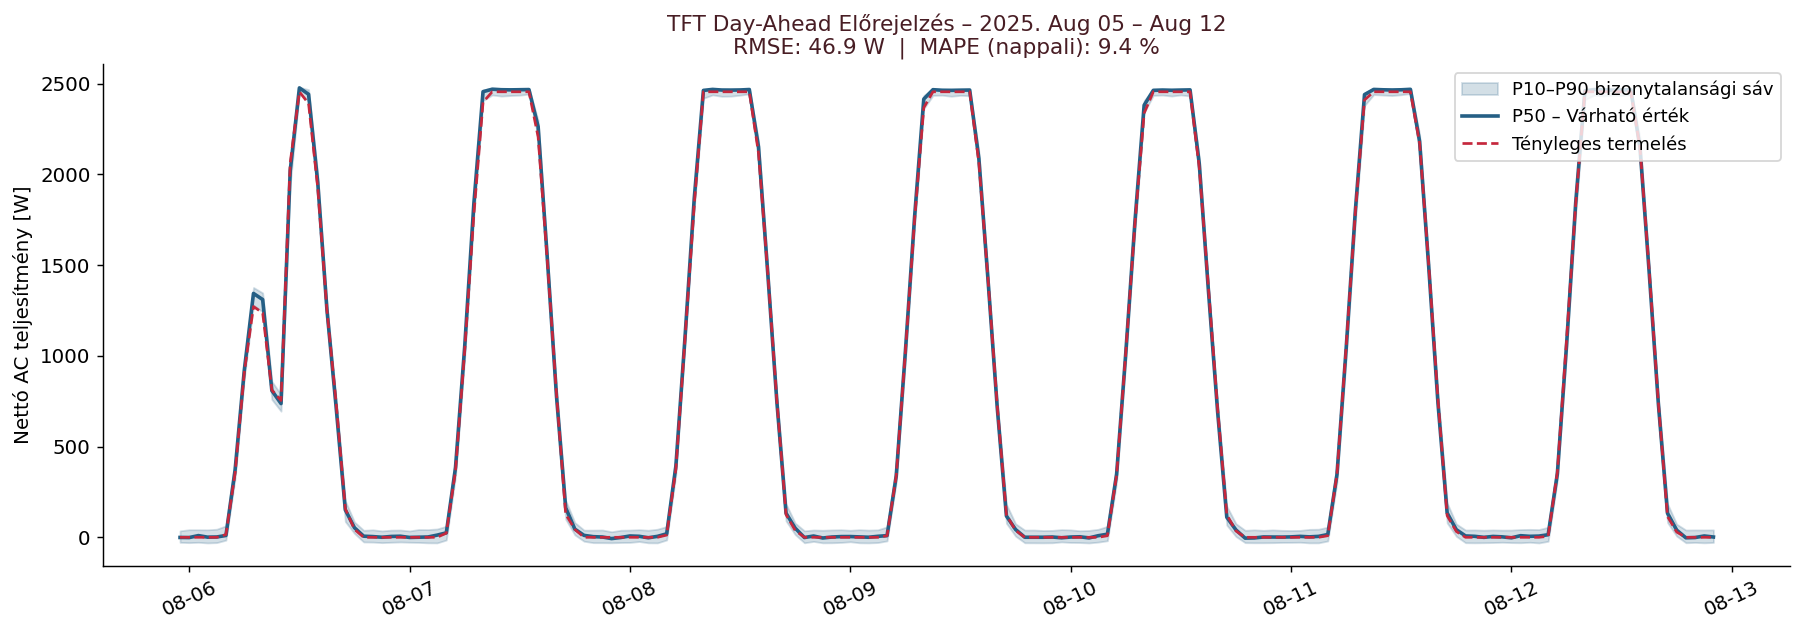

In [13]:
# Véletlen hét kiválasztása a tényleges backtest időszakból
bt_start    = backtest_p50.time_index[0]
bt_end      = backtest_p50.time_index[-1]
max_offset  = int((bt_end - bt_start).days / 7) - 1  # utolsó teljes hét indexe

week_offset = random.randint(0, max_offset)           # minden futáskor más hét
week_start  = bt_start + pd.Timedelta(weeks=week_offset)
week_end    = week_start + pd.Timedelta(days=6, hours=23)

print(f"Vizualizált hét: {week_start.date()} – {week_end.date()}  (offset: {week_offset}/{max_offset})")

# Adatok kivágása – az előre kiszámolt backtest_p10/p50/p90 változók újrahasználata
actual_week = ts_test_actual.slice(week_start, week_end).to_dataframe().squeeze()
p10_week    = backtest_p10.slice(week_start, week_end).to_dataframe().squeeze()
p50_week    = backtest_p50.slice(week_start, week_end).to_dataframe().squeeze()
p90_week    = backtest_p90.slice(week_start, week_end).to_dataframe().squeeze()

# Grafikon
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    p50_week.index, p10_week, p90_week,
    alpha=0.20, color=COLORS.get("ac", "#255f85"),
    label="P10–P90 bizonytalansági sáv",
)
ax.plot(
    p50_week.index, p50_week,
    color=COLORS.get("ac", "#255f85"), lw=2.0,
    label="P50 – Várható érték",
)
ax.plot(
    actual_week.index, actual_week,
    color=COLORS.get("loss", "#c5283d"), lw=1.5, ls="--",
    label="Tényleges termelés",
)

ax.set_title(
    f"TFT Day-Ahead Előrejelzés – {week_start.strftime('%Y. %b %d')} – {week_end.strftime('%b %d')}\n"
    f"RMSE: {rmse_val:.1f} W  |  MAPE (nappali): {mape_val:.1f} %",
    fontsize=12, color=COLORS.get("title", "#481d24"),
)
ax.set_ylabel("Nettó AC teljesítmény [W]")
ax.set_xlabel("")
ax.legend(loc="upper right", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

---
## 4.12. Vizualizáció – Napi MAPE Naptár Hőtérkép (2025)

Az egész tesztelési év (365 nap) előrejelzési hibáját egyetlen naptárszerű ábra mutatja. Minden négyzet egy napot jelöl; a szín intenzitása a napi MAPE értéket kódolja (csak nappali, > 5 W termelésű órák alapján számolva).

- **Zöld** napok: a TFT szinte tökéletesen megjósolta a termelést
- **Piros** napok: bizonytalan időjárás (borult, változékony), ahol a fizikai szimulációs előrejelzés is nehéz lenne
- **Szürke** cellák: téli napok, ahol gyakorlatilag nincs nappali termelés (MAPE értelmezhetetlen)
<div style="display: flex; flex-direction: column; gap: 14px; margin: 16px 0; font-family: sans-serif;">
  
  <div style="background: #e0f2fe; border-left: 6px solid #0284c7; border-radius: 8px; padding: 16px 18px;">
    <div style="font-size: 20px; font-weight: 900; color: #0369a1; margin-bottom: 8px;">Összegzés: A modell jó, de az időjárás a szűk keresztmetszet</div>
    <div style="font-size: 13.5px; color: #0c4a6e; line-height: 1.6;">
      A két naptár közötti jelentős különbséget <b>kizárólag a bemeneti adatok pontossága okozza</b>. Maga a TFT modell rendkívül pontosan megtanulta a rendszer fizikáját, a kiugró hibát a valódi üzemet szimuláló meteorológiai előrejelzések (NWP) bizonytalansága okozza.
    </div>
  </div>

  <div style="display: flex; gap: 14px;">
    
    <div style="flex: 1; background: #f0fdf4; border-left: 6px solid #16a34a; border-radius: 8px; padding: 16px 18px;">
      <div style="font-size: 18px; font-weight: 900; color: #15803d; margin-bottom: 4px;">Ideális Bemenet (ERA5)</div>
      <div style="font-size: 12px; font-weight: 700; color: #166534; margin-bottom: 10px; text-transform: uppercase; letter-spacing: 0.5px;">Tényadatokon alapuló múltbeli időjárás</div>
      <div style="font-size: 24px; font-weight: 900; color: #16a34a; margin-bottom: 8px;">MAPE: 9.4% <span style="font-size: 11px; font-weight: normal; color: #475569;"></span></div>
      <div style="font-size: 12.5px; color: #1e293b; line-height: 1.6;">A modell a tényleges időjárást ismerve szinte tökéletes előrejelzést ad. Ez igazolja, hogy <b>a modellünk helyes és megbízható</b>.</div>
    </div>

    <div style="flex: 1; background: #fff7ed; border-left: 6px solid #ea580c; border-radius: 8px; padding: 16px 18px;">
      <div style="font-size: 18px; font-weight: 900; color: #c2410c; margin-bottom: 4px;">Valós Üzem (Forecast API)</div>
      <div style="font-size: 12px; font-weight: 700; color: #9a3412; margin-bottom: 10px; text-transform: uppercase; letter-spacing: 0.5px;">Életszerű day-ahead előrejelzés</div>
      <div style="font-size: 24px; font-weight: 900; color: #ea580c; margin-bottom: 8px;">MAPE: 38.4% <span style="font-size: 11px; font-weight: normal; color: #475569;"></span></div>
      <div style="font-size: 12.5px; color: #1e293b; line-height: 1.6;">A megnövekedett hiba oka nem a gépi tanulás hiányossága, hanem a másnapi meteorológiai előrejelzés gyakori pontatlansága.</div>
    </div>
    
  </div>
</div>

──────────────────────────────────────────────────────────────
  1/2  ERA5 Reanalízis – ideális bemenet (archive API)
──────────────────────────────────────────────────────────────


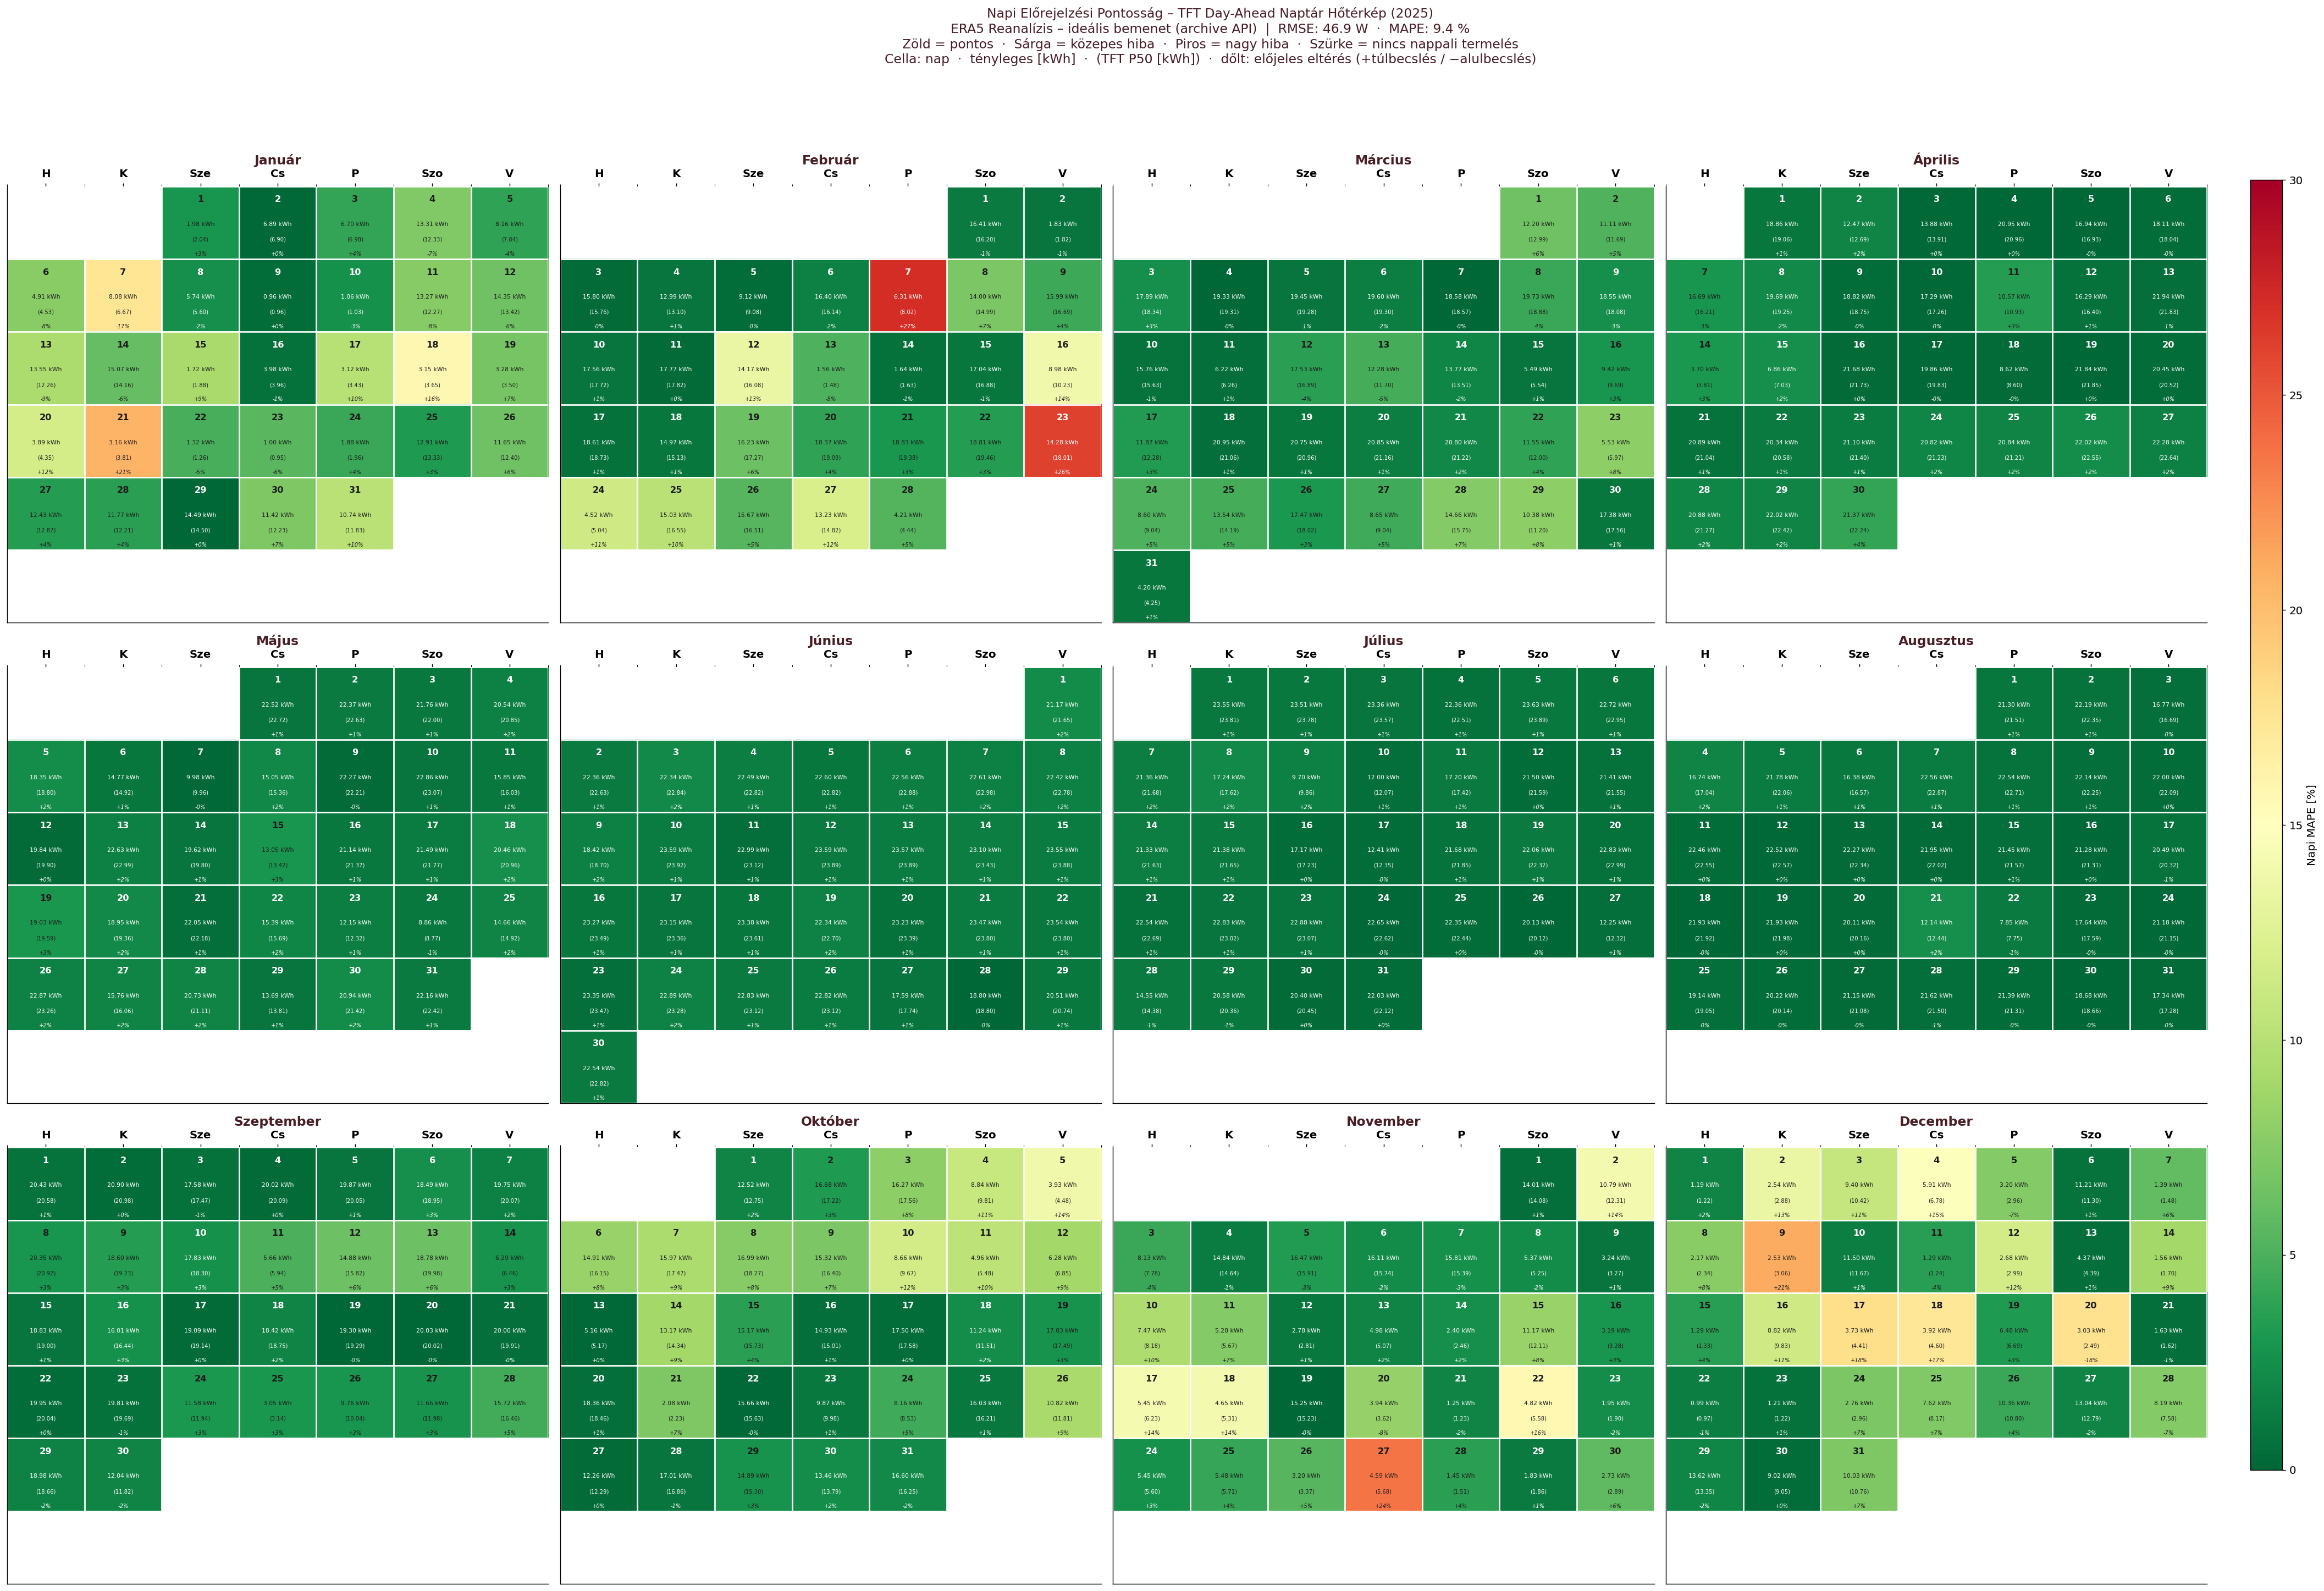

  Legjobb nap   : 2025-01-29  →  MAPE = 0.0 %
  Legrosszabb   : 2025-02-07  →  MAPE = 27.1 %
  Éves átlag    : 3.4 %  (napsütéses napok)

──────────────────────────────────────────────────────────────
  2/2  Forecast API – életszerű day-ahead bemenet
──────────────────────────────────────────────────────────────


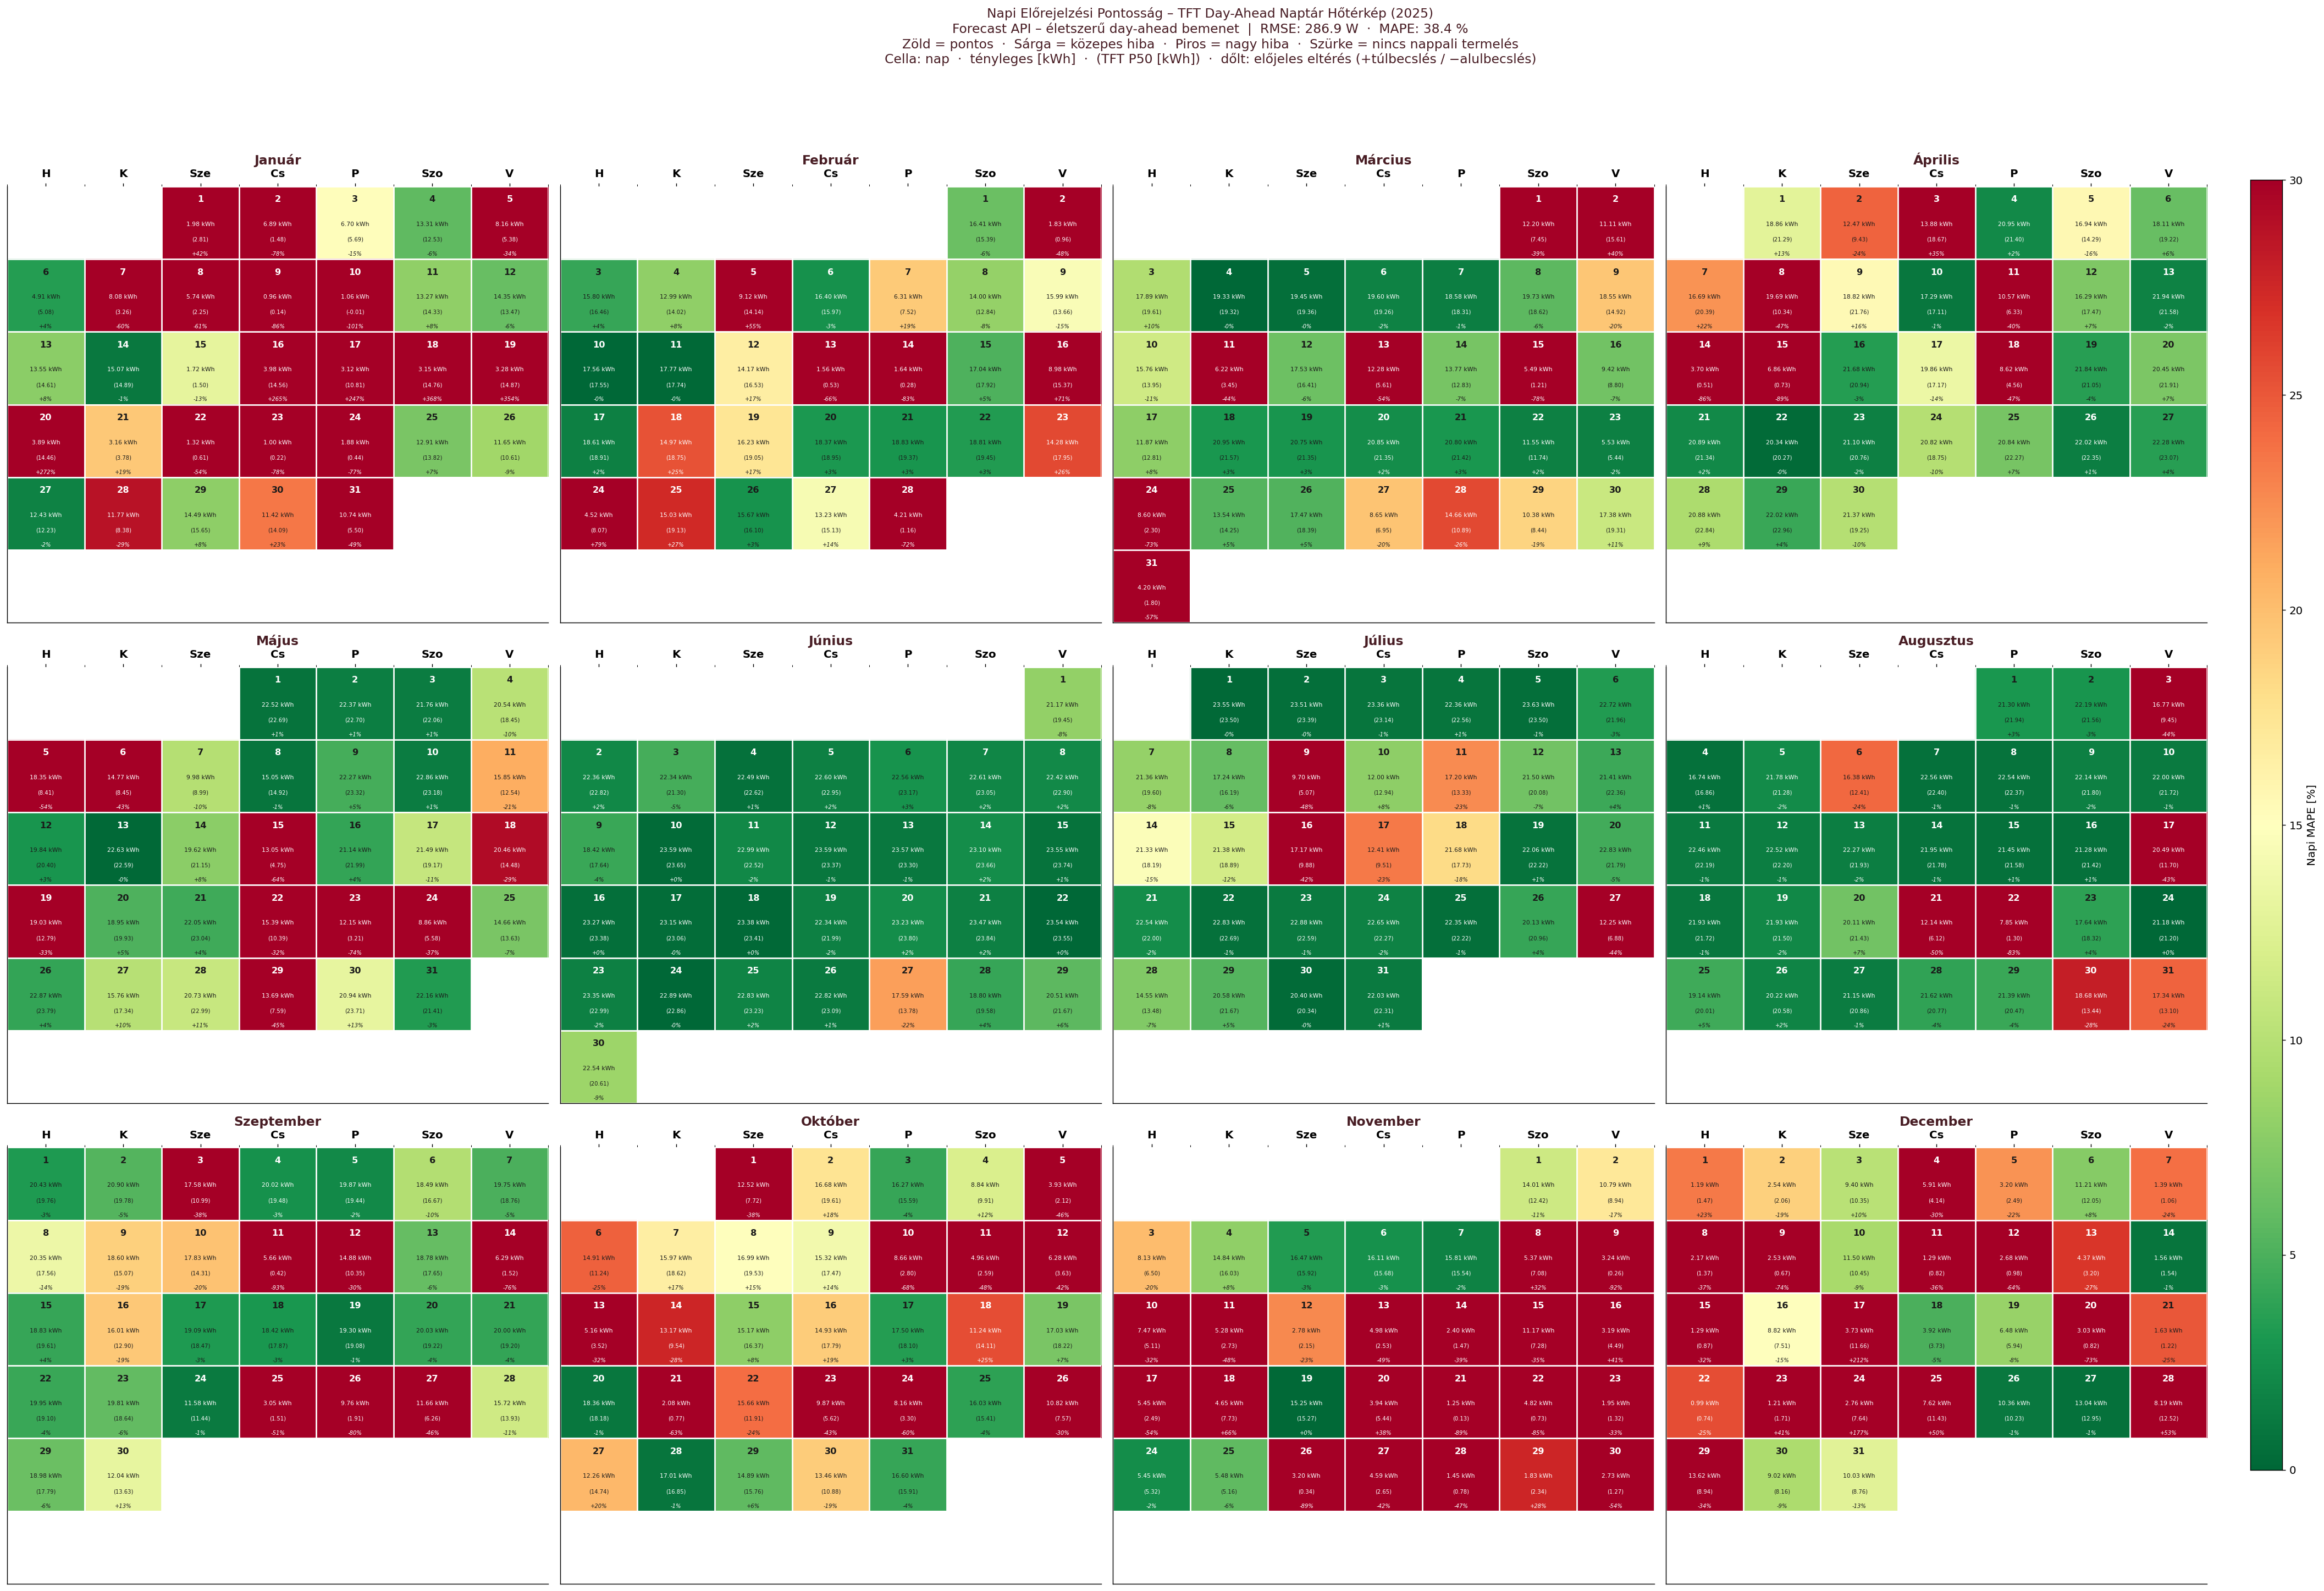

  Legjobb nap   : 2025-03-04  →  MAPE = 0.0 %
  Legrosszabb   : 2025-01-18  →  MAPE = 367.9 %
  Éves átlag    : 24.7 %  (napsütéses napok)


In [14]:
# ─── 13. Vizualizáció: Napi MAPE Naptár Hőtérkép (2025) ────────────────────────
# Két naptár: ERA5 (ideális) és Forecast API (életszerű day-ahead bemenet)
import calendar as _cal

_year        = 2025
_month_names = ["Január", "Február", "Március", "Április", "Május", "Június",
                "Július", "Augusztus", "Szeptember", "Október", "November", "December"]
_day_labels  = ["H", "K", "Sze", "Cs", "P", "Szo", "V"]
_cmap_cal    = plt.cm.RdYlGn_r
_norm_cal    = matplotlib.colors.Normalize(vmin=0, vmax=30)

# Tényleges termelés helyi időindexen (UTC-naív + 1h ≈ Budapest)
_cal_local_idx    = actual_s.index + pd.Timedelta(hours=1)
_actual_cal       = pd.Series(actual_s.values, index=_cal_local_idx)
_actual_cal       = _actual_cal[_actual_cal.index.year == _year]
_daytime_cal      = _actual_cal > 5.0
_daily_actual_kwh = (
    _actual_cal[_daytime_cal].groupby(_actual_cal[_daytime_cal].index.date).sum() / 1000
).to_dict()


def _draw_calendar_heatmap(pred_s: pd.Series, title: str, rmse: float, mape: float) -> None:
    """3×4 hónapos naptár hőtérkép a megadott P50 előrejelzési sorozathoz."""
    _pred_cal = pd.Series(pred_s.values, index=_cal_local_idx)
    _pred_cal = _pred_cal[_pred_cal.index.year == _year]
    _pred_dt  = _pred_cal[_daytime_cal]
    _daily_pred_kwh = (_pred_dt.groupby(_pred_dt.index.date).sum() / 1000).to_dict()

    _mape_dict = {}
    _mpe_dict  = {}
    for _d, _a in _daily_actual_kwh.items():
        _p = _daily_pred_kwh.get(_d)
        if _p is None or _a < 0.01:
            continue
        _mape_dict[_d] = abs(_p - _a) / _a * 100
        _mpe_dict[_d]  = (_p - _a)    / _a * 100

    fig, axes = plt.subplots(3, 4, figsize=(34, 22))
    fig.suptitle(
        f"Napi Előrejelzési Pontosság – TFT Day-Ahead Naptár Hőtérkép (2025)\n"
        f"{title}  |  RMSE: {rmse:.1f} W  ·  MAPE: {mape:.1f} %\n"
        "Zöld = pontos  ·  Sárga = közepes hiba  ·  Piros = nagy hiba  ·  Szürke = nincs nappali termelés\n"
        "Cella: nap  ·  tényleges [kWh]  ·  (TFT P50 [kWh])  ·  dőlt: előjeles eltérés (+túlbecslés / −alulbecslés)",
        fontsize=13, color=COLORS.get("title", "#481d24"), y=1.01,
    )

    for _m_idx in range(12):
        _m  = _m_idx + 1
        ax  = axes[_m_idx // 4][_m_idx % 4]
        _first_dow   = _cal.weekday(_year, _m, 1)
        _days_in_mon = _cal.monthrange(_year, _m)[1]

        _mg      = np.full((6, 7), np.nan)
        _mg_act  = np.full((6, 7), np.nan)
        _mg_pred = np.full((6, 7), np.nan)
        _mg_mpe  = np.full((6, 7), np.nan)
        _mg_day  = np.full((6, 7), np.nan)

        for _dn in range(1, _days_in_mon + 1):
            _date = pd.Timestamp(f"{_year}-{_m:02d}-{_dn:02d}").date()
            _wr   = (_dn - 1 + _first_dow) // 7
            _dc   = (_dn - 1 + _first_dow) % 7
            _mg_day[_wr, _dc] = _dn
            if (_v := _mape_dict.get(_date)) is not None:
                _mg[_wr, _dc] = float(_v)
            if (_s := _mpe_dict.get(_date)) is not None:
                _mg_mpe[_wr, _dc] = float(_s)
            if (_a := _daily_actual_kwh.get(_date)) is not None:
                _mg_act[_wr, _dc] = float(_a)
            if (_p := _daily_pred_kwh.get(_date)) is not None:
                _mg_pred[_wr, _dc] = float(_p)

        ax.imshow(_mg, aspect="auto", cmap=_cmap_cal, norm=_norm_cal, origin="upper")
        ax.set_xticks(np.arange(-0.5, 7.5, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 6.5, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.5)
        ax.tick_params(which="minor", bottom=False, left=False)
        ax.set_xticks(range(7))
        ax.set_xticklabels(_day_labels, fontsize=11, fontweight="bold")
        ax.xaxis.set_ticks_position("top")
        ax.xaxis.set_label_position("top")
        ax.set_yticks([])
        ax.set_xlim(-0.5, 6.5)
        ax.set_ylim(5.5, -0.5)
        ax.set_title(_month_names[_m_idx], fontsize=13, fontweight="bold",
                     color=COLORS.get("title", "#481d24"), pad=22)

        for _wr in range(6):
            for _dc in range(7):
                _dn   = _mg_day[_wr, _dc]
                _mape = _mg[_wr, _dc]
                _mpe  = _mg_mpe[_wr, _dc]
                _act  = _mg_act[_wr, _dc]
                _pred = _mg_pred[_wr, _dc]
                if np.isnan(_dn):
                    continue
                if np.isnan(_mape):
                    _tc = "#555555"
                else:
                    _rgba = _cmap_cal(_norm_cal(_mape))
                    _lum  = 0.2126 * _rgba[0] + 0.7152 * _rgba[1] + 0.0722 * _rgba[2]
                    _tc   = "white" if _lum < 0.45 else "#1a1a1a"
                ax.text(_dc, _wr - 0.32, f"{int(_dn)}",
                        ha="center", va="center", fontsize=9, color=_tc, fontweight="bold")
                if not np.isnan(_act):
                    ax.text(_dc, _wr + 0.02, f"{_act:.2f} kWh",
                            ha="center", va="center", fontsize=6.0, color=_tc)
                    ax.text(_dc, _wr + 0.23, f"({_pred:.2f})",
                            ha="center", va="center", fontsize=5.5, color=_tc)
                if not np.isnan(_mpe):
                    ax.text(_dc, _wr + 0.43, f"{_mpe:+.0f}%",
                            ha="center", va="center", fontsize=5.5, color=_tc, style="italic")

    plt.tight_layout(rect=[0, 0, 0.915, 0.97])
    _cax = fig.add_axes([0.928, 0.08, 0.013, 0.82])
    _sm  = plt.cm.ScalarMappable(cmap=_cmap_cal, norm=_norm_cal)
    _sm.set_array([])
    _cb  = fig.colorbar(_sm, cax=_cax, label="Napi MAPE [%]")
    _cb.ax.tick_params(labelsize=11)
    plt.show()

    _no_nan = pd.Series(_mape_dict).dropna()
    print(f"  Legjobb nap   : {_no_nan.idxmin()}  →  MAPE = {_no_nan.min():.1f} %")
    print(f"  Legrosszabb   : {_no_nan.idxmax()}  →  MAPE = {_no_nan.max():.1f} %")
    print(f"  Éves átlag    : {_no_nan.mean():.1f} %  (napsütéses napok)")


# ── 1/2  ERA5 Reanalízis (ideális: tökéletes archív időjárás-bemenet) ────────
print("─" * 62)
print("  1/2  ERA5 Reanalízis – ideális bemenet (archive API)")
print("─" * 62)
_draw_calendar_heatmap(
    pred_s=p50_s,
    title="ERA5 Reanalízis – ideális bemenet (archive API)",
    rmse=rmse_val,
    mape=mape_val,
)

# ── 2/2  Forecast API (életszerű: valódi NWP day-ahead előrejelzés-bemenet) ──
print("\n" + "─" * 62)
print("  2/2  Forecast API – életszerű day-ahead bemenet")
print("─" * 62)
_draw_calendar_heatmap(
    pred_s=p50_fc_s,
    title="Forecast API – életszerű day-ahead bemenet",
    rmse=rmse_fc_val,
    mape=mape_fc_val,
)


---
## 4.13. Vizualizáció – Hónap × Óra Átlagos Termelési Profil

Ez a 3 paneles hőtérkép egyszerre mutatja az **évszakos** és **napszakos** mintázatokat.

- **Első panel:** a vizsgált 2023–2025-ös időszak hároméves tényleges termelés átlaga (hónap × óra bontásban)
- **Középső panel:** TFT P50 előrejelzés – a modell 2025-ös átlagos hónap/óra profilja
- **Harmadik panel:** abszolút eltérés – a hároméves tényleges átlag és a 2025-ös P50 közötti különbség

Az **inverter clipping** hatása: a nyári déli sávban (Máj–Aug, 08–12 UTC) a termelési profil "levágódik" a 3 kW-os inverter korlátján.

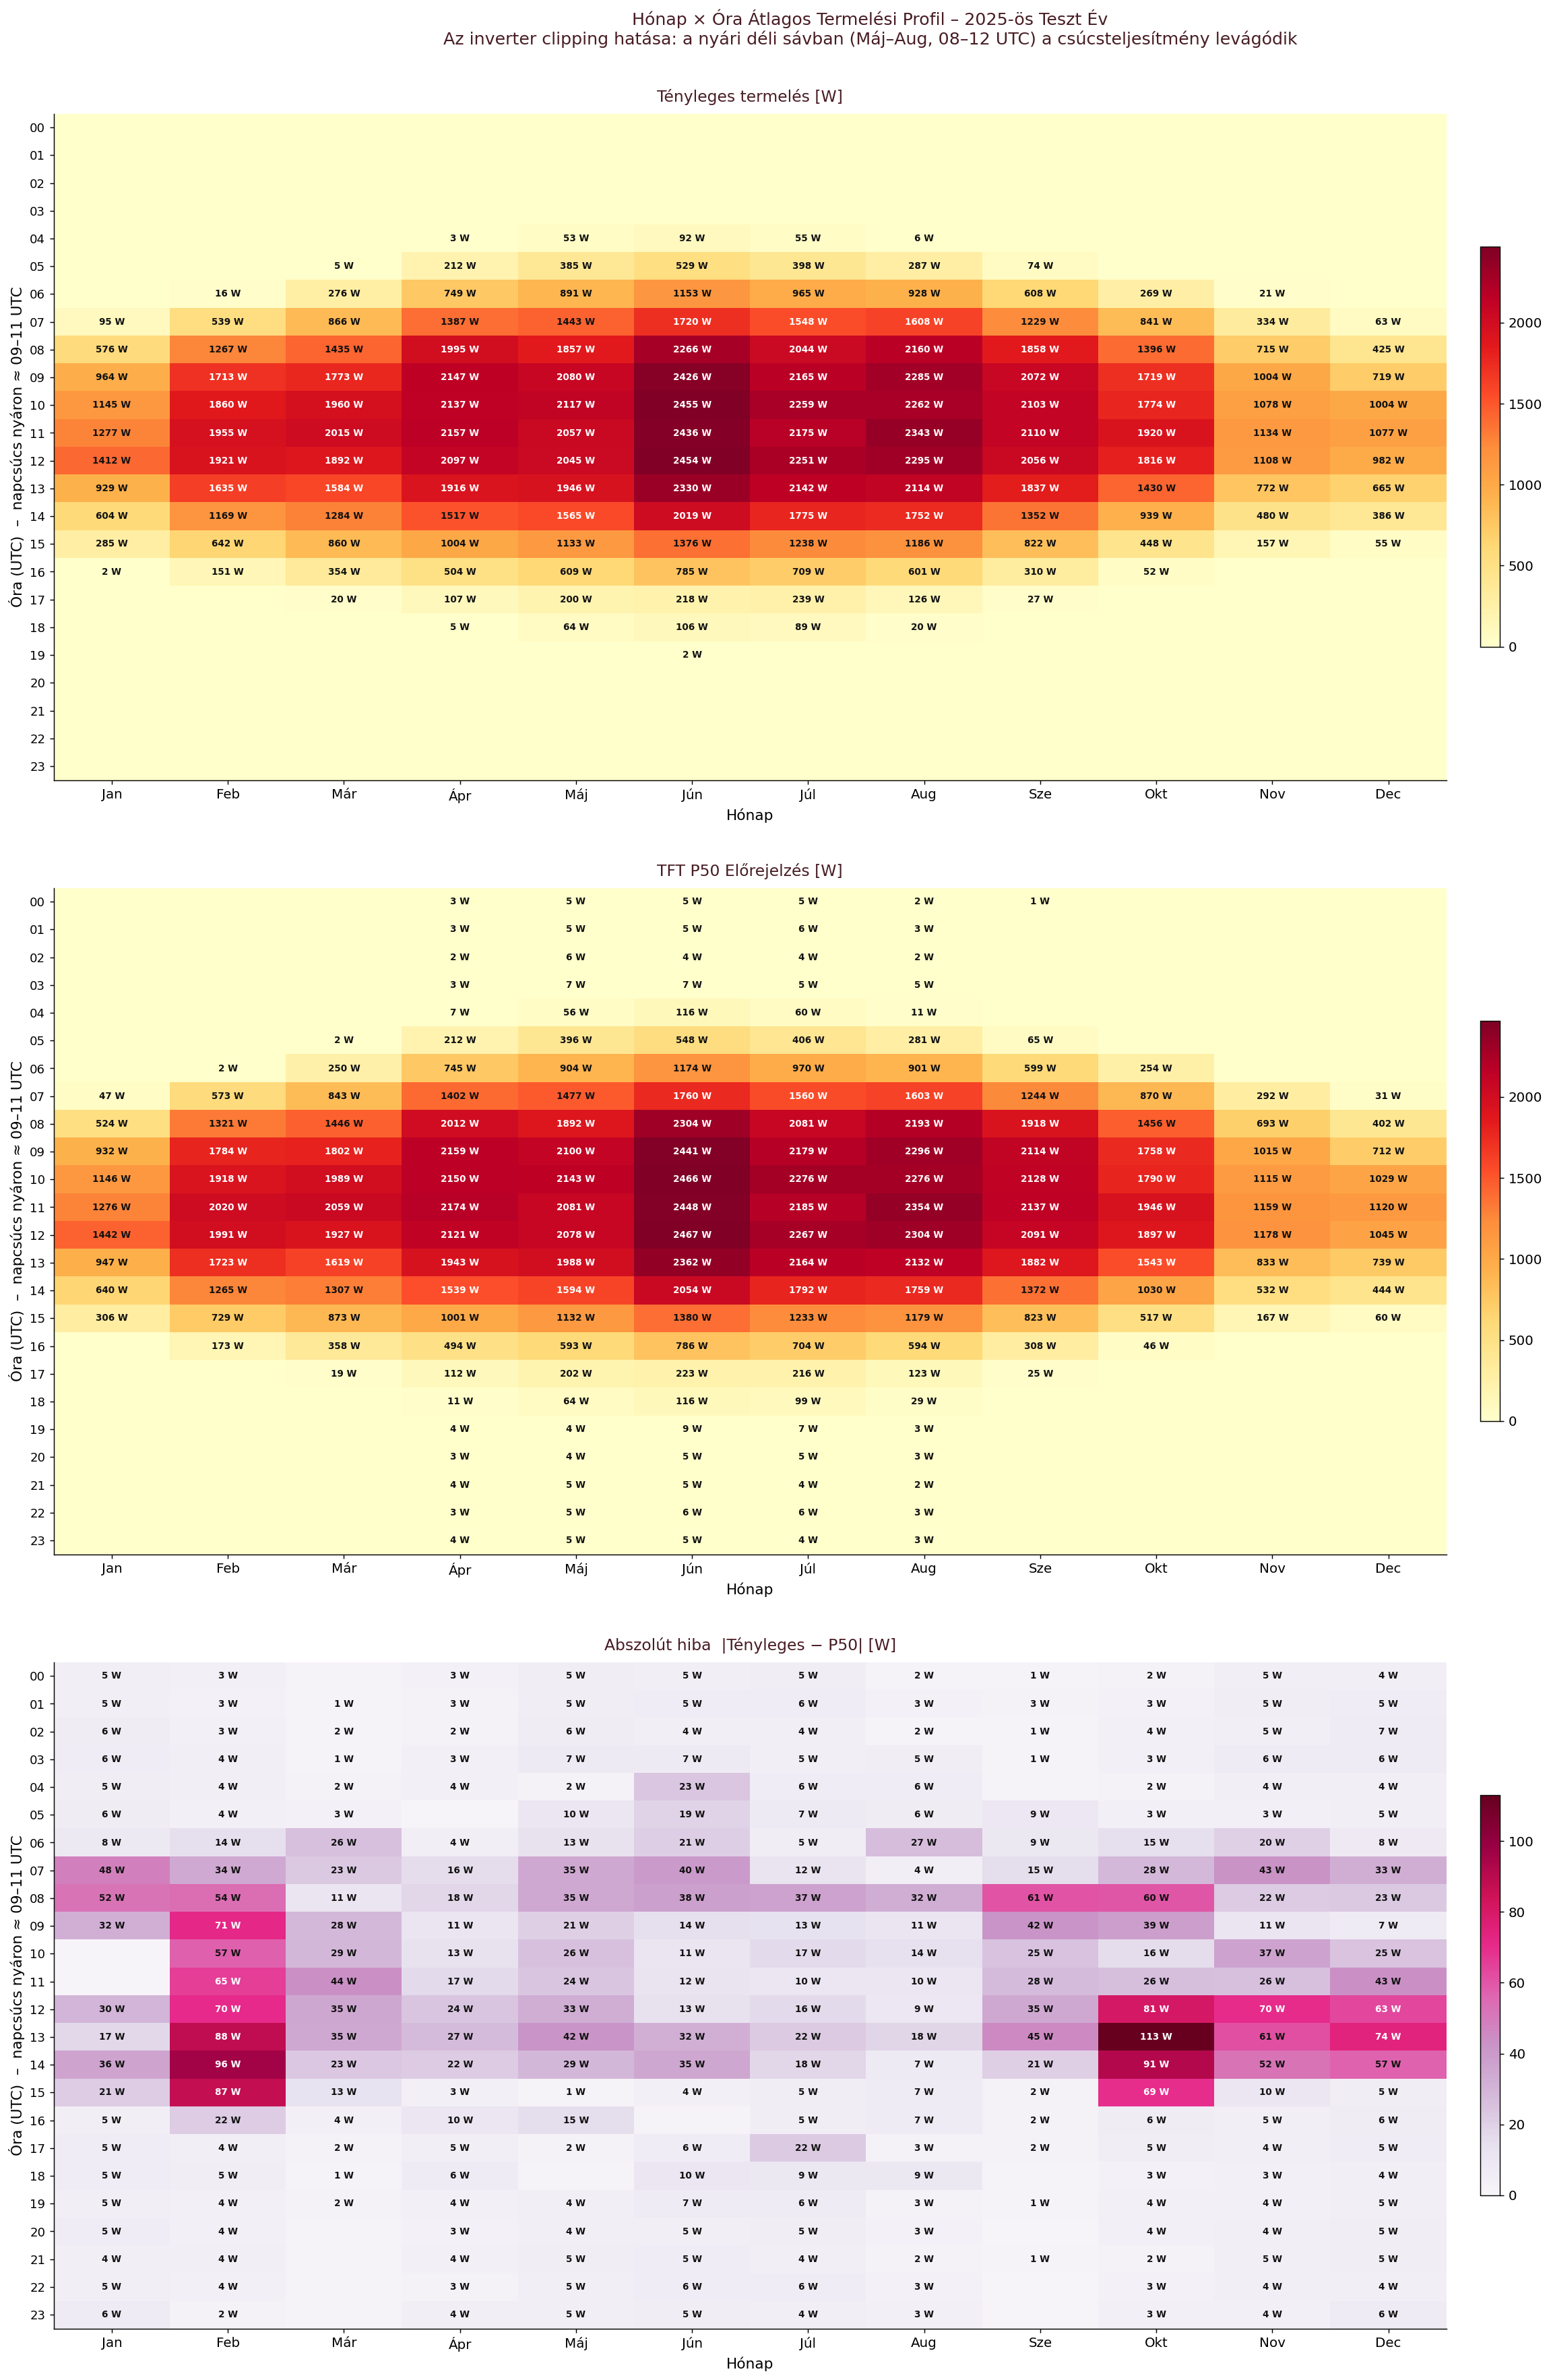

In [ ]:
# ─── 14. Vizualizáció: Hónap × Óra Átlagos Termelési Profil (3 panel) ──────────

_actual_all = ts_target.to_dataframe().squeeze().rename("actual")
_actual_all = _actual_all[_actual_all.index.year.isin([2023, 2024, 2025])]
_df_act = pd.DataFrame({
    "actual": _actual_all.values,
    "month":  _actual_all.index.month,
    "hour":   _actual_all.index.hour,
})
_df_pred = pd.DataFrame({
    "predicted": p50_s.values,
    "month":      p50_s.index.month,
    "hour":       p50_s.index.hour,
})

# A tényleges termelésnél a teljes 2023–2025-ös vizsgált időszak hároméves átlagát jelenítjük meg.
_piv_act  = _df_act.groupby(["month", "hour"])["actual"].mean().unstack("month")
_piv_pred = _df_pred.groupby(["month", "hour"])["predicted"].mean().unstack("month")
_piv_err  = (_piv_act - _piv_pred).abs()

# Teljes 24×12 mátrix garantálva
_piv_act  = _piv_act.reindex(index=range(24), columns=range(1, 13)).fillna(0.0)
_piv_pred = _piv_pred.reindex(index=range(24), columns=range(1, 13)).fillna(0.0)
_piv_err  = _piv_err.reindex(index=range(24), columns=range(1, 13)).fillna(0.0)

_MON = ["Jan", "Feb", "Már", "Ápr", "Máj", "Jún",
        "Júl", "Aug", "Sze", "Okt", "Nov", "Dec"]
_vmax_prod = float(np.nanmax([_piv_act.values.max(), _piv_pred.values.max()]))
_vmax_err  = float(np.nanmax(_piv_err.values))

fig, axes = plt.subplots(3, 1, figsize=(20, 27))

_panels = [
    (_piv_act,  "YlOrRd", 0, _vmax_prod, "Tényleges termelés (2023–2025 átlag) [W]"),
    (_piv_pred, "YlOrRd", 0, _vmax_prod, "TFT P50 Előrejelzés [W]"),
    (_piv_err,  "PuRd",   0, _vmax_err,  "Abszolút eltérés (hároméves átlag vs. P50) [W]"),
]
for panel_idx, (ax, (piv, cmap, vmin, vmax, title)) in enumerate(zip(axes, _panels)):
    _im = ax.imshow(piv.values, aspect="auto", cmap=cmap,
                    vmin=vmin, vmax=vmax, origin="upper")
    _cb = plt.colorbar(_im, ax=ax, shrink=0.6, pad=0.02, orientation="vertical")
    _cb.ax.tick_params(labelsize=11)
    ax.set_xticks(range(12))
    ax.set_xticklabels(_MON, fontsize=11)
    ax.set_yticks(range(0, 24, 1))
    ax.set_yticklabels([f"{h:02d}" for h in range(0, 24, 1)], fontsize=10)
    ax.set_xlabel("Hónap", fontsize=12)
    ax.set_ylabel("Óra (UTC)  –  napcsúcs nyáron ≈ 09–11 UTC", fontsize=12)
    ax.set_title(title, fontsize=13, color=COLORS.get("title", "#481d24"), pad=10)

    # numerikus értékek cellánként (mindhárom panel)
    _cmap_panel = plt.cm.get_cmap(cmap)
    _norm_panel = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    for _h in range(24):
        for _m_idx in range(12):
            _val = piv.values[_h, _m_idx]
            if _val < 1.0:      # éjszakai nullákat kihagyjuk
                continue
            _rgba = _cmap_panel(_norm_panel(_val))
            _lum  = 0.2126 * _rgba[0] + 0.7152 * _rgba[1] + 0.0722 * _rgba[2]
            _tc   = "white" if _lum < 0.45 else "#111111"
            ax.text(_m_idx, _h, f"{_val:.0f} W", ha="center", va="center",
                    fontsize=7.5, color=_tc, fontweight="bold")

fig.suptitle(
    "Hónap × Óra Átlagos Termelési Profil – 2023–2025 hároméves átlag\n"
    "A bal panel a vizsgált három év tényleges hónap/óra átlagát mutatja.",
    fontsize=14, color=COLORS.get("title", "#481d24"), y=1.005,
)
plt.tight_layout(h_pad=3.0)
plt.show()

---
## 4.14. (Opcionális) Modell mentése / betöltése

In [16]:
# A mentés automatikus volt (save_checkpoints=True), a legjobb checkpoint újratölthető:
# model_loaded = TFTModel.load_from_checkpoint("solar_tft_model", best=True)

# Kézi mentés (opcionális):
model.save("models/solar_tft_model_manual.pt")

print("Modell checkpoint automatikusan mentve (save_checkpoints=True).")
print("Újratöltés: TFTModel.load_from_checkpoint('solar_tft_model', best=True)")

Modell checkpoint automatikusan mentve (save_checkpoints=True).
Újratöltés: TFTModel.load_from_checkpoint('solar_tft_model', best=True)
